## Task 1

The connection sketches are presented as follows:
### Filter:

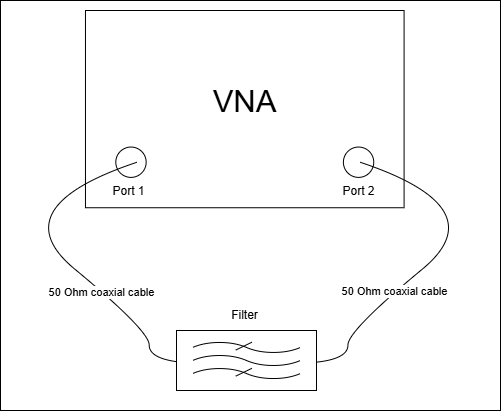

### Circulator:
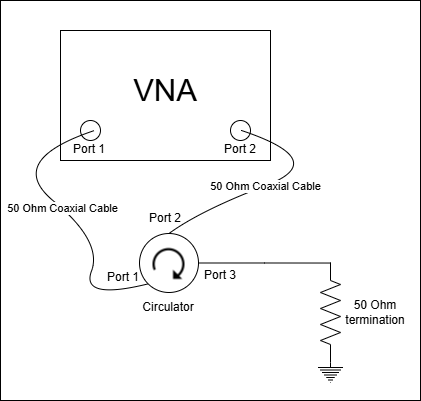

### Coupler:
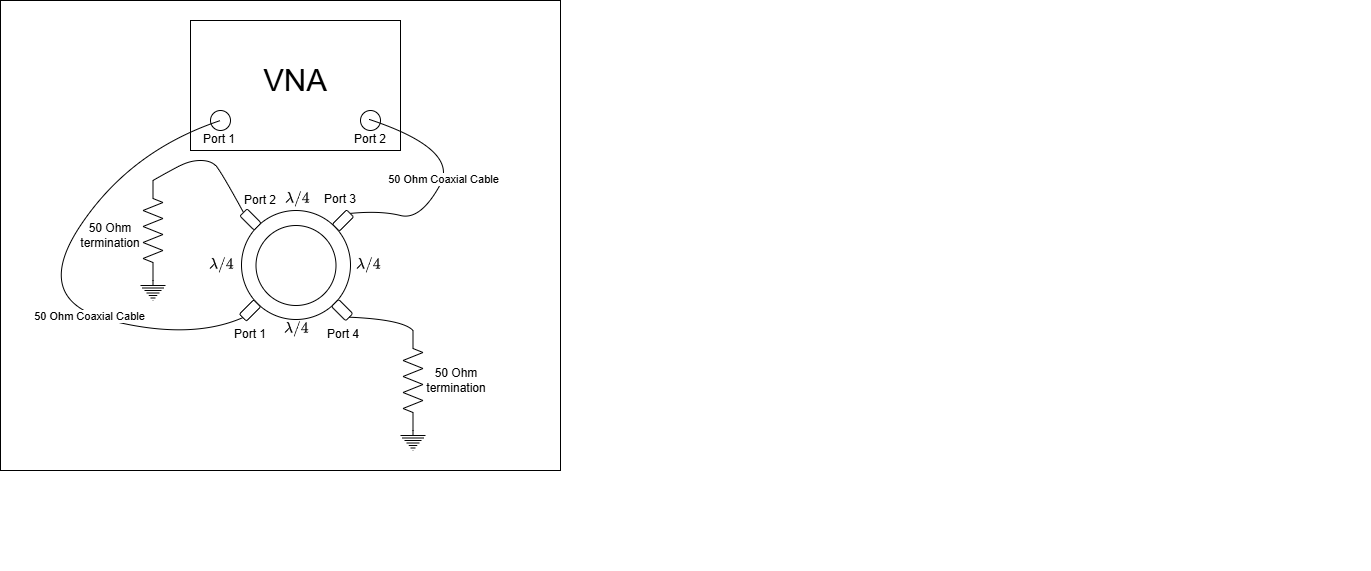

### Line:
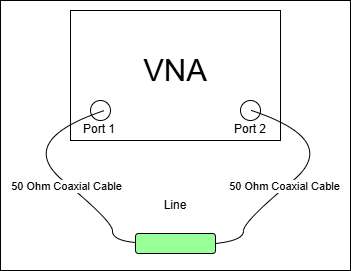

### Wilkinson Divider:
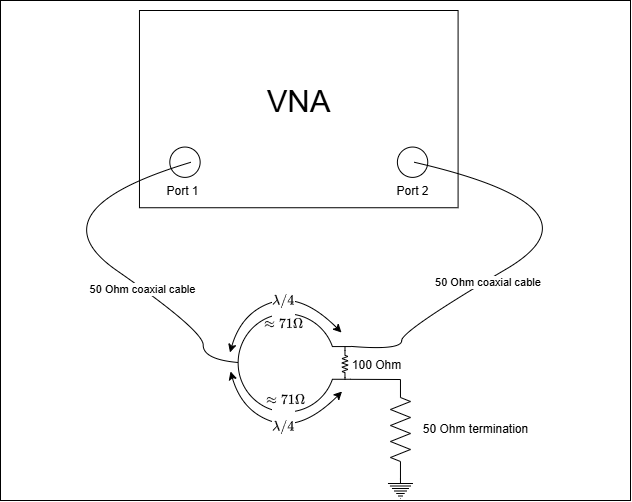

## Task 3

When measuring S-parameters using a vector network analyzer (VNA), imperfections in the instrument, cables, and switching system introduce systematic errors. To correct for these, mathematical error models are used during calibration. Depending on the level of precision required and the type of measurement setup, different models are applied:

#### 16-Term Model
This is the most detailed model available. It accounts for all linear and systematic errors, including directivity, port match, tracking, leakage paths, and switch behavior. It's especially useful when working with wafer probes, fixtures, or setups where isolation and repeatability are more difficult to control.

#### 12-Term Model
A commonly used model in standard 2-port VNAs. It splits the error correction into six terms for the forward direction and six for the reverse. It captures the main sources of error like directivity, reflection/transmission tracking, and port mismatch. Assumes stable switching and relatively low leakage. Often used with SOLT calibration.

#### 8-Term Model
A simplified model that assumes perfect switching and negligible leakage. It models errors using two 2-port adapters — one at each port of the DUT. This model is efficient and accurate in modern VNAs with four receivers and is typically used with TRL calibration methods or when working with well-matched, symmetric setups.

| Model     | Terms | Assumptions                   | Best Suited For                     |
|-----------|-------|-------------------------------|-------------------------------------|
| 16-Term   | 16    | No assumptions                | Complex or high-precision setups    |
| 12-Term   | 12    | Ignores switch mismatch       | Standard lab measurements (SOLT)    |
| 8-Term    | 8     | Ideal switch, no leakage      | TRL calibration, modern instruments |




### Task 4

In microwave engineering, coaxial cables are commonly standardized to a characteristic impedance of **50 ohms**. This value does not represent the theoretical optimum for any single performance metric, but instead reflects a practical compromise between two competing factors: **power handling capacity** and **signal attenuation**. As shown below, 30 Ω provides maximum power handling, while 77 Ω minimizes attenuation. The choice of 50 Ω offers a well-balanced solution suitable for most RF applications.

---

### 1. Maximum Power Handling

The peak power that a coaxial cable can handle is limited by the electric field strength at the inner conductor, which must not exceed the dielectric breakdown threshold.

**Electric field at the inner conductor:**

$$
E_{\text{max}} = \frac{V}{a \ln(b/a)}
$$

Solving for the maximum voltage before breakdown (\(E_{\text{break}}\)):

$$
V_{\text{max}} = E_{\text{break}} \cdot a \ln(b/a)
$$

The power delivered to a matched load is:

$$
P = \frac{V_{\text{max}}^2}{2Z_0}
$$

Substituting the expression for \(V_{\text{max}}\):

$$
P \propto \frac{a^2 \ln^2(b/a)}{Z_0}
$$

Using the characteristic impedance formula:

$$
Z_0 = \frac{60}{\sqrt{\varepsilon_r}} \ln(b/a)
$$

we can express power as:

$$
P \propto \frac{a^2 \ln(b/a)}{60}
$$

This function reaches its maximum when \(Z_0 \approx 30\ \Omega\), indicating that coaxial lines with lower impedance support higher power levels before breakdown.

---

### 2. Minimum Attenuation

In the low-loss approximation, the attenuation constant \( \alpha \) for a coaxial cable dominated by conductor loss is given by:

$$
\alpha \approx \frac{R_s}{2Z_0} \left( \frac{1}{a} + \frac{1}{b} \right)
$$

where \(R_s\) is the surface resistance, and \(Z_0\) is again:

$$
Z_0 = \frac{60}{\sqrt{\varepsilon_r}} \ln(b/a)
$$

Substituting and minimizing \(\alpha\) with respect to the ratio \(b/a\) leads to an optimal impedance of:

$$
Z_0 \approx 77\ \Omega
$$

This value minimizes attenuation from conductor loss.

The follwing is demonstrated in the plo generated b running the following snipet which computes a sweep of the derved equations for minimizing loss and maximizing power coupling.

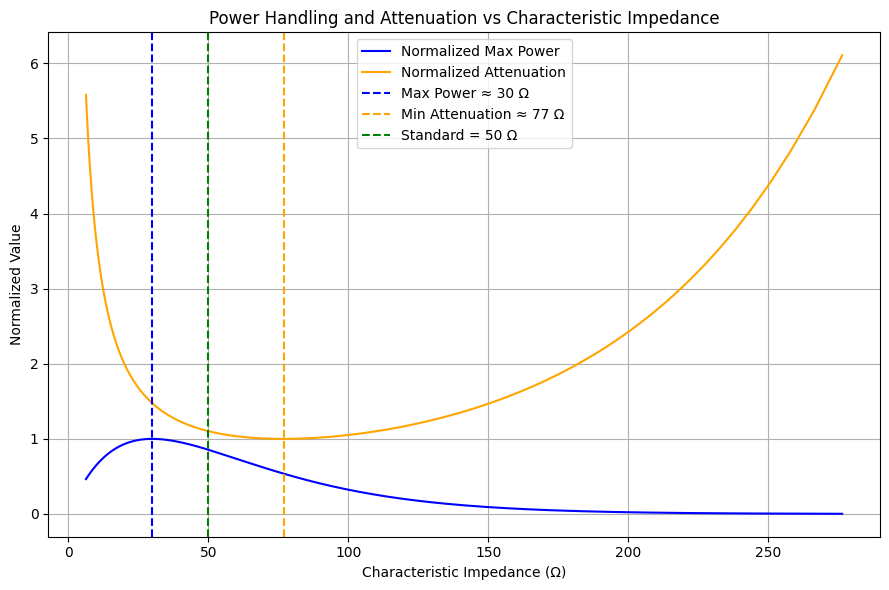

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
b = 1.0  # outer conductor radius (normalized)
epsilon_r = 1.0  # air dielectric constant

# Sweep inner conductor radius a
a = np.linspace(0.01, 0.9 * b, 500)
ln_ba = np.log(b / a)

# Characteristic impedance in air
Z0 = 60 / np.sqrt(epsilon_r) * ln_ba

# --- Power Handling Calculation ---
# V_max ∝ a * ln(b/a)
Vmax = a * ln_ba
# P ∝ V^2 / (2Z0)
P = Vmax**2 / (2 * Z0)
P_normalized = P / np.max(P)

# --- Attenuation Calculation ---
# α ∝ (1/a + 1/b) / Z0
alpha = (1 / Z0) * (1 / a + 1 / b)
alpha_normalized = alpha / np.min(alpha)

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.plot(Z0, P_normalized, label='Normalized Max Power', color='blue')
plt.plot(Z0, alpha_normalized, label='Normalized Attenuation', color='orange')

# Vertical lines for reference
plt.axvline(30, color='blue', linestyle='--', label='Max Power ≈ 30 Ω')
plt.axvline(77, color='orange', linestyle='--', label='Min Attenuation ≈ 77 Ω')
plt.axvline(50, color='green', linestyle='--', label='Standard = 50 Ω')

# Labels and styling
plt.xlabel('Characteristic Impedance (Ω)')
plt.ylabel('Normalized Value')
plt.title('Power Handling and Attenuation vs Characteristic Impedance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()